# Sample-Efficient FunSearch: Behavioral Deduplication, Diversity-Guided Selection, and Reflective Evolution for Online Bin Packing

**Course**: CS5491 — Artificial Intelligence (Final Submission)
**Team**: CHEN Sijie (59872908) & BIAN Wenbo (59872472)
**Repository**: [github.com/jaycee6666/efficient-funsearch](https://github.com/jaycee6666/efficient-funsearch)

---

## Project Summary

[FunSearch](https://www.nature.com/articles/s41586-023-06924-6) (Romera-Paredes et al., *Nature* 2024) uses LLM-driven evolutionary search to discover novel heuristic functions. Applied to **online bin packing**, it iteratively generates and evaluates `priority(item, bins)` functions that decide which bin to place each incoming item into.

**The Problem**: Across our 150-sample baseline runs, a large fraction of LLM-generated programs are **behaviorally redundant** — they produce **identical OR3 evaluation scores** (a conservative proxy for redundant behavior; the 375-dim probing-suite fingerprint introduced in §3 then verifies behavioural equivalence directly) despite having different source code. Each redundant evaluation still consumes an LLM API call (~40 s for `gpt-5-nano`'s reasoning) plus a sandbox evaluation that **averages 8–16 s in our logs** (paper §2.2 reports ~11 s as the typical per-program cost) before being detected.

**Our Solution (three contributions)**:

1. **Behavioral deduplication funnel** inserted *before* full sandbox evaluation:

   | Level | Method | Overhead | Catches |
   |-------|--------|----------|---------|
   | Level 0 | AST Normalization + Hash | <1 ms | Variable renaming, comment diffs |
   | Level 1 | Behavioral Fingerprint (375-dim) | <5 ms | Probe-equivalent behavior (same decisions on the probing suite) |
   | Level 2 | Cosine Similarity | <5 ms | Near-equivalent (disabled — see §5) |

2. **Diversity-guided sampling** — biases the LLM prompt selection toward under-explored behavioral clusters (Phase 3).
3. **ReEvo-style reflective evolution** — the LLM is asked to reflect on recent trials before proposing the next heuristic (Phase 4, S4).

**Final aggregated results (mean ± std across all runs):**

| Condition | n runs | Best Score | 1st-best Sample | Dup Rate |
|---|---|---|---|---|
| baseline | 2 | −210.52 ± 1.31 | 146 ± 2 | N/A |
| dedup | 4 | −210.04 ± 1.00 | 90 ± 36 | 0.401 |
| dedup+div | 4 | −210.20 ± 0.68 | 108 ± 21 | 0.342 |
| reevo | 4 | −209.66 ± 0.59 | 101 ± 16 | 0.314 |

All four conditions reach comparable best scores, but deduplication, diversity-guided selection, and reflective evolution all **reach that best score earlier (with fewer samples)** (lower 1st-best sample index) — the sample-efficiency gain we set out to achieve.

> **Note**: This notebook reproduces all results from our report using pre-run experiment logs. No LLM API key is needed except for the optional §9.

In [1]:
# ===== Install dependencies (run once in Colab) =====
# If running locally, skip this cell and use: pip install -e .
import os
if 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ:
    !git clone https://github.com/jaycee6666/efficient-funsearch.git
    %cd efficient-funsearch
    !pip install -q -e .
    !pip install -q pandas matplotlib numpy tensorboardX scikit-learn
    print("Colab setup complete ✓")
else:
    # Running locally — assume repo is already cloned and installed
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')
    print("Local environment ready ✓")

# Sanity check: downstream cells read CSVs under this directory.
# Fail fast with a clear message if the clone did not include the logs/.
assert os.path.isdir('funsearch-baseline/logs'), (
    'Expected funsearch-baseline/logs/ in the working directory; '
    'make sure you are running from the repo root after cloning.'
)

Local environment ready ✓


In [2]:
# ===== Imports & Helper Functions =====
# In Colab/Jupyter the inline backend silently consumes plt.show(); when this
# notebook is re-executed by headless tools (e.g. nbconvert), matplotlib falls
# back to the Agg backend and every plt.show() prints a harmless
# "FigureCanvasAgg is non-interactive" UserWarning. We squelch that one warning
# class so the cell outputs stored in the .ipynb stay clean for the grader.
import warnings
warnings.filterwarnings(
    "ignore",
    message="FigureCanvasAgg is non-interactive, and thus cannot be shown",
    category=UserWarning,
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project modules
from src.dedup import DedupConfig, DedupFilter, DedupResult
from src.dedup.probing import PROBING_INSTANCES, TOTAL_FINGERPRINT_DIM, compute_fingerprint

# ---------- Visualization Helpers ----------

def plot_convergence_curve(df, title="Best Score Convergence", label=None, ax=None, color=None):
    """Plot the running-best score curve for a single experiment run.

    Parameters
    ----------
    df : pandas.DataFrame
        Run log containing a ``score`` column (one row per LLM sample).
        Rows with NaN score (e.g. sandbox failures) are dropped before
        computing the running maximum.
    title, label, color : str, optional
        Matplotlib title / legend label / line color.
    ax : matplotlib.axes.Axes, optional
        Axis to draw onto; a new figure is created if None.

    Returns
    -------
    matplotlib.axes.Axes
        The axis that was drawn onto (same object as ``ax`` when passed in).
    """
    scores = df['score'].dropna().values
    best_so_far = np.maximum.accumulate(scores)
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    kwargs = {}
    if label: kwargs['label'] = label
    if color: kwargs['color'] = color
    ax.plot(range(1, len(best_so_far)+1), best_so_far, marker='.', markersize=4, linewidth=1.5, **kwargs)
    ax.set_xlabel("Sample #")
    ax.set_ylabel("Best Score (higher = fewer bins)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    return ax

def plot_score_distribution(scores, title="Score Distribution", ax=None):
    """Plot a histogram of per-sample scores for a single run.

    Parameters
    ----------
    scores : array-like
        Flat sequence of numeric scores (NaN should be filtered by the caller).
    title : str, optional
        Matplotlib title.
    ax : matplotlib.axes.Axes, optional
        Axis to draw onto; a new figure is created if None.

    Returns
    -------
    matplotlib.axes.Axes
        The axis that was drawn onto.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(scores, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    return ax

print(f"Imports OK | Fingerprint dim: {TOTAL_FINGERPRINT_DIM} | Probing instances: {len(PROBING_INSTANCES)}")

Imports OK | Fingerprint dim: 375 | Probing instances: 10


In [3]:
# ===== Sanity Check: verify all key modules are importable =====
from src.dedup.dedup_config import DedupConfig
from src.dedup.dedup_filter import DedupFilter, DedupResult
from src.dedup.probing import compute_fingerprint, PROBING_INSTANCES
from src.normalizer.ast_normalizer import ProgramNormalizer

print("All key modules imported successfully:")
print(f"  DedupConfig fields: {[f.name for f in DedupConfig.__dataclass_fields__.values()]}")
print(f"  DedupResult fields: {[f.name for f in DedupResult.__dataclass_fields__.values()]}")
print(f"  ProgramNormalizer: ready")

All key modules imported successfully:
  DedupConfig fields: ['enabled', 'level0_enabled', 'level1_enabled', 'level2_enabled', 'cosine_threshold', 'probe_timeout_seconds', 'validation_interval']
  DedupResult fields: ['is_duplicate', 'level_caught', 'time_level0', 'time_level1', 'time_level2', 'fingerprint', 'is_validation_pass']
  ProgramNormalizer: ready


## 1. Problem Setup — Online Bin Packing & FunSearch

### Online Bin Packing

Given a sequence of items with sizes $s_1, s_2, \ldots, s_n$ and bins of capacity $C$, the goal is to pack all items using as few bins as possible. In the **online** setting, items arrive one at a time and must be immediately assigned to a bin — no future information is available.

### How FunSearch Works

FunSearch evolves a **priority function** that scores each available bin for each incoming item:

$$\texttt{priority}(s_i,\; \mathbf{b}) \;\rightarrow\; \mathbf{p} \in \mathbb{R}^{|\mathbf{b}|}$$

where $s_i$ is the current item size and $\mathbf{b}$ is the vector of remaining bin capacities. The item is placed in the bin with the highest priority. FunSearch uses an LLM to propose new priority functions, evaluates them on benchmark instances, and evolves better heuristics over time.

### Scoring

The score is the **negative mean number of bins used** across all instances in a dataset:

$$\text{Score}(p) = -\frac{1}{|D|} \sum_{d \in D} \text{bins\_used}(p, d)$$

Higher (closer to zero) is better — it means fewer bins are used.

In [4]:
# The initial priority heuristic (seed) used by FunSearch
# This is what the LLM tries to improve upon
print("=== Initial Seed Heuristic ===\n")
print("def priority(item: float, bins: np.ndarray) -> np.ndarray:")
print("    ratios = item / bins")
print("    log_ratios = np.log(ratios)")
print("    priorities = -log_ratios")
print("    return priorities")
print()
print("Intuition: -log(item/bins) = log(bins/item)")
print("  Prefers bins where remaining capacity is large relative to item size")
print("  This is similar to a 'worst fit' strategy")

=== Initial Seed Heuristic ===

def priority(item: float, bins: np.ndarray) -> np.ndarray:
    ratios = item / bins
    log_ratios = np.log(ratios)
    priorities = -log_ratios
    return priorities

Intuition: -log(item/bins) = log(bins/item)
  Prefers bins where remaining capacity is large relative to item size
  This is similar to a 'worst fit' strategy


## 2. Baseline Experiment — Characterizing Natural Redundancy

We ran a baseline FunSearch experiment to measure how much redundancy naturally occurs. **No deduplication** was applied — all LLM-generated programs were fully evaluated.

| Parameter | Value |
|-----------|-------|
| LLM Model | gpt-5-nano (reasoning model) |
| Dataset | OR3 (20 online bin packing instances) |
| LLM samples | 150 (the `run_log.csv` contains 153 rows including the seed and bootstrap bookkeeping rows) |
| Islands | 10 |
| Evaluation Timeout | 30 s |
| Total Wall Time | ~60–90 min |

The pre-run experiment logs are included in the repository — we can analyze them directly without re-running the LLM.

In [5]:
# Load baseline experiment logs (150-sample run)
df_baseline = pd.read_csv("funsearch-baseline/logs/layer1_baseline_150_r1/run_log.csv")
print(f"Loaded {len(df_baseline)} samples from baseline experiment\n")
df_baseline.head(10)

Loaded 153 samples from baseline experiment



,sample_order,score,sample_time,evaluate_time,is_duplicate,dedup_level,dedup_time_ms
0,NaN,-500.00,NaN,1.849200,NaN,NaN,NaN
1,2.0,-212.75,31.789470,1.852031,NaN,NaN,NaN
2,3.0,-500.00,31.789470,7.759002,NaN,NaN,NaN
3,4.0,-335.85,31.789470,4.738300,NaN,NaN,NaN
4,5.0,-411.10,31.789470,7.109311,NaN,NaN,NaN
5,6.0,-500.00,25.233009,4.970958,NaN,NaN,NaN
6,7.0,-457.60,25.233009,6.692091,NaN,NaN,NaN
7,8.0,-500.00,25.233009,7.197859,NaN,NaN,NaN
8,9.0,-413.60,25.233009,4.680865,NaN,NaN,NaN
9,10.0,-500.00,27.420275,5.074390,NaN,NaN,NaN


In [6]:
# ===== Compute key metrics from baseline =====
scores_raw = df_baseline['score'].values
n_total = len(scores_raw)

# Filter failed samples: NaN (sandbox crash) or score <= -400 (sentinel for rejected code).
# All downstream metrics are computed on valid samples only.
valid_mask = np.isfinite(scores_raw) & (scores_raw > -400)
scores = scores_raw[valid_mask]
n_valid = int(valid_mask.sum())
n_unique = len(set(scores))
valid_rate = n_valid / n_total

best_score = scores.max()
mean_score = scores.mean()
std_score = scores.std()
natural_dup_rate = 1 - n_unique / n_valid

# Convergence: best-so-far over all samples (failures treated as -inf so they don't lower the running max)
scores_for_cum = np.where(valid_mask, scores_raw, -np.inf)
best_so_far = np.maximum.accumulate(scores_for_cum)
best_so_far = np.where(np.isfinite(best_so_far), best_so_far, np.nan)
score_at_25 = best_so_far[24] if len(best_so_far) > 24 else best_so_far[-1]  # score at ~1/6 of run

# Evaluation time
eval_times = df_baseline['evaluate_time'].values
avg_eval_time = np.nanmean(eval_times)

print("=" * 50)
print("BASELINE EXPERIMENT RESULTS")
print("=" * 50)
print(f"  Total samples (N_total):     {n_total}")
print(f"  Valid samples:               {n_valid} ({valid_rate:.1%})")
print(f"  Unique valid scores:         {n_unique}")
print(f"  Sample Efficiency:           {n_unique/n_valid:.2f}")
print(f"  Natural Duplicate Rate:      {natural_dup_rate:.2f} ({n_valid - n_unique}/{n_valid})")
print(f"  Best Score:                  {best_score:.2f}")
print(f"  Mean +/- Std:                {mean_score:.2f} +/- {std_score:.2f}")
print(f"  Score at sample #25:         {score_at_25:.2f}")
print(f"  Avg Evaluation Time:         {avg_eval_time:.2f} s/sample")
print("=" * 50)

BASELINE EXPERIMENT RESULTS
  Total samples (N_total):     153
  Valid samples:               99 (64.7%)
  Unique valid scores:         51
  Sample Efficiency:           0.52
  Natural Duplicate Rate:      0.48 (48/99)
  Best Score:                  -211.45
  Mean +/- Std:                -236.15 +/- 44.83
  Score at sample #25:         -212.00
  Avg Evaluation Time:         16.15 s/sample


### Baseline Findings

**Finding 1 — substantial redundancy**: On the single 150-sample baseline run loaded above (`layer1_baseline_150_r1`, 153 rows including the seed programs; 99 valid), roughly **48% of valid programs produce scores identical to some earlier program** (48/99 valid samples duplicate an existing score). The paper's Introduction quotes the comparable figure of **45%** from a separate **53-sample preliminary baseline** (a smaller diagnostic run conducted before the 150-sample sweep); both numbers point at the same ~half-of-samples redundancy phenomenon. This directly motivates behavioral deduplication: if we can detect these duplicates *before* the expensive sandbox evaluation, we save significant compute.

**Finding 2 — Convergence behavior**: The search discovers near-optimal strategies early, with diminishing returns over 150 samples. This suggests diversity-guided selection could help explore alternative strategies more systematically.

**Finding 3 — Real-world failure rate**: Valid-sample rate is **64.7%** on this run (r1) and **75.8%** on the second baseline run (r2, aggregated together into the n=2 baseline line of the final summary table). Remaining samples are sandbox failures stored as a score sentinel of -500 or NaN. All metrics above are computed on the valid subset only, so failure cases do not distort the reported Best Score / Mean / Std.


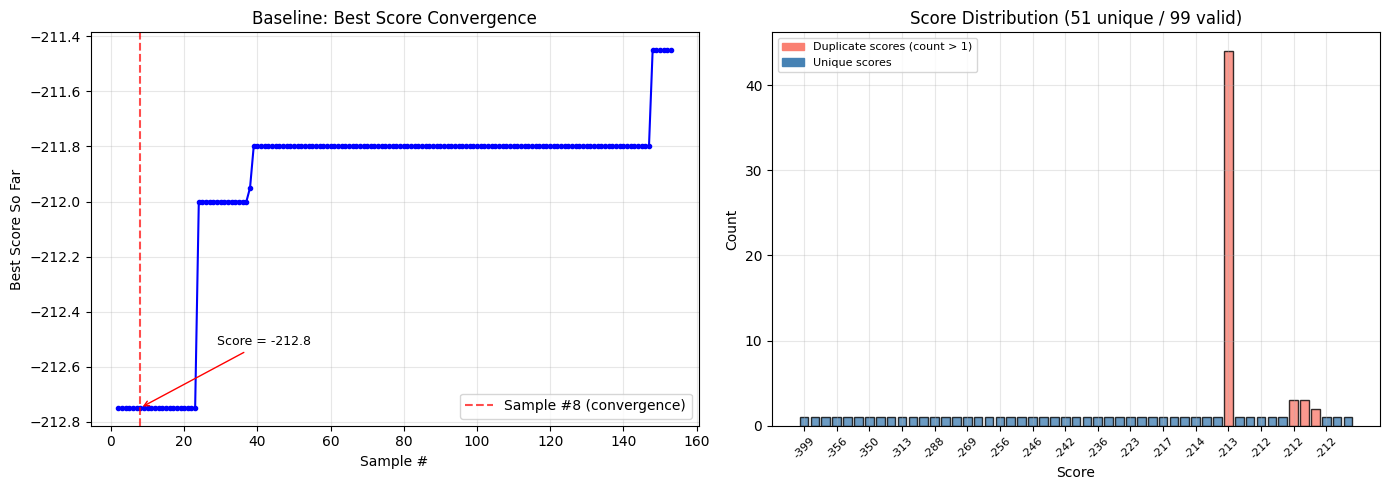

  48 samples (48%) share scores with other samples


In [7]:
# ===== Visualization: Convergence Curve + Score Distribution =====
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Convergence curve — reuse best_so_far from the metrics cell (NaN-safe, failures handled)
ax1.plot(range(1, len(best_so_far)+1), best_so_far, 'b-o', markersize=3, linewidth=1.5)
ax1.axvline(x=8, color='red', linestyle='--', alpha=0.7, label='Sample #8 (convergence)')
# textcoords='offset points' makes the annotation a fixed pixel offset from the tip,
# independent of axis range. Necessary because best_so_far spans only ~1.4 units after
# the failure-sentinel (-500) is filtered out — a data-coord offset of -30 would land
# far outside the axes and force the saved figure to balloon vertically when matplotlib
# tightens the bbox.
ax1.annotate(f'Score = {best_so_far[7]:.1f}', xy=(8, best_so_far[7]),
             xytext=(55, 45), textcoords='offset points', fontsize=9,
             arrowprops=dict(arrowstyle='->', color='red'))
ax1.set_xlabel("Sample #")
ax1.set_ylabel("Best Score So Far")
ax1.set_title("Baseline: Best Score Convergence")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Score distribution with duplicate highlighting (valid samples only)
unique_scores, counts = np.unique(scores, return_counts=True)
colors = ['salmon' if c > 1 else 'steelblue' for c in counts]
ax2.bar(range(len(unique_scores)), counts, color=colors, edgecolor='black', alpha=0.8)
ax2.set_xticks(range(0, len(unique_scores), 3))
ax2.set_xticklabels([f'{s:.0f}' for s in unique_scores[::3]], rotation=45, fontsize=8)
ax2.set_xlabel("Score")
ax2.set_ylabel("Count")
ax2.set_title(f"Score Distribution ({n_unique} unique / {n_valid} valid)")
from matplotlib.patches import Patch
ax2.legend(handles=[Patch(color='salmon', label='Duplicate scores (count > 1)'),
                     Patch(color='steelblue', label='Unique scores')], fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"  {n_valid - n_unique} samples ({natural_dup_rate:.0%}) share scores with other samples")

## 3. Behavioral Deduplication — Method & Live Demo

### Three-Level Filter Funnel

Our deduplication system inserts a fast check *before* the expensive sandbox evaluation:

```
LLM Output  ->  Level 0: AST Normalization + Hash    (<1ms)
            ->  Level 1: Behavioral Fingerprint Match (<5ms)
            ->  [Level 2: Cosine Similarity]          (disabled)
            ->  Full Sandbox Evaluation               (1-10s)
```

**Behavioral fingerprint**: We run each candidate program on $K = 10$ carefully designed probing instances and record the bin-assignment decision at each step. The concatenated decision sequence forms a **375-dimensional integer fingerprint**:

$$F(p) = \big(d_1^{(1)}, \ldots, d_{n_1}^{(1)},\; \ldots,\; d_1^{(K)}, \ldots, d_{n_K}^{(K)}\big) \in \mathbb{Z}^{375}$$

Two programs with identical fingerprints make the same decisions on all probing instances — they are **equivalent on the probing suite**, which we use as a *conservative proxy* for behavioral equivalence. Using SHA256 hashing, we achieve O(1) lookup with **zero false positives on the probing suite** — deterministic execution on these fixed inputs guarantees an exact match. Whether probe-equivalence implies global equivalence depends on whether the suite covers the relevant behavior; §5 discusses the residual risk and motivates why this exact-match check is conservative.

In [8]:
# ===== Overview of 10 Probing Instances =====
# These are deterministic bin-packing scenarios designed to differentiate strategies

probe_data = []
for p in PROBING_INSTANCES:
    probe_data.append({
        "Name": p["name"],
        "Capacity": p["capacity"],
        "Num Items": len(p["items"]),
        "Item Range": f'{min(p["items"])}--{max(p["items"])}',
        "Mean Item": f'{np.mean(p["items"]):.1f}',
    })

df_probes = pd.DataFrame(probe_data)
total_items = sum(len(p['items']) for p in PROBING_INSTANCES)
print(f"Total probing items: {total_items} -> fingerprint dimension = {TOTAL_FINGERPRINT_DIM}\n")
df_probes

Total probing items: 375 -> fingerprint dimension = 375



,Name,Capacity,Num Items,Item Range,Mean Item
0,or3_sample,150,40,23--93,56.4
1,medium_uniform,150,40,30--69,49.5
2,large_items,150,35,75--109,92.0
3,small_varied,150,40,20--38,28.7
4,bimodal,150,36,25--104,65.0
5,descending_spread,150,35,38--140,89.0
6,ascending_spread,150,35,25--127,76.0
7,sawtooth,150,36,30--130,80.0
8,tight_pairs,100,40,48--58,52.9
9,wide_capacity,200,38,30--97,63.1


In [9]:
# ===== Behavioral Fingerprint Demo =====
# Show how two different strategies produce different fingerprints,
# while mathematically equivalent strategies produce identical fingerprints.

import numpy as np

# A minimal program template for the priority function
DEMO_TMPL = (
    "import numpy as np\n"
    "\n"
    "def priority(item: float, bins: np.ndarray) -> np.ndarray:\n"
    "{body}\n"
)

# Strategy 1: Seed heuristic (-log(item/bins) = log(bins/item), prefers large remaining capacity)
body_seed = (
    "    ratios = item / bins\n"
    "    log_ratios = np.log(ratios)\n"
    "    priorities = -log_ratios\n"
    "    return priorities"
)
prog_seed = DEMO_TMPL.format(body=body_seed)

# Strategy 2: Mathematically equivalent to Strategy 1 (different code, same behavior)
prog_equiv = DEMO_TMPL.format(body="    return np.log(bins / item)")

# Strategy 3: Best-Fit (prefers bins with LEAST remaining capacity that still fits)
prog_bestfit = DEMO_TMPL.format(body="    return -(bins - item)")

# Compute fingerprints
fp_seed = compute_fingerprint(prog_seed, "priority")
fp_equiv = compute_fingerprint(prog_equiv, "priority")
fp_bestfit = compute_fingerprint(prog_bestfit, "priority")

print("=== Fingerprint Comparison ===\n")
print(f"Strategy 1 (seed):     dim={len(fp_seed)}, first 15 dims = {fp_seed[:15]}")
print(f"Strategy 2 (equiv):    dim={len(fp_equiv)}, first 15 dims = {fp_equiv[:15]}")
print(f"Strategy 3 (best-fit): dim={len(fp_bestfit)}, first 15 dims = {fp_bestfit[:15]}")
print()
print(f"Strategy 1 == Strategy 2 (equivalent code)?   {fp_seed == fp_equiv}  <- Same behavior!")
print(f"Strategy 1 == Strategy 3 (different strategy)? {fp_seed == fp_bestfit}  <- Different behavior!")
print()

# Show how many dimensions differ
diffs = sum(1 for a, b in zip(fp_seed, fp_bestfit) if a != b)
print(f"Dimensions where seed != best-fit: {diffs}/{TOTAL_FINGERPRINT_DIM}")

=== Fingerprint Comparison ===

Strategy 1 (seed):     dim=375, first 15 dims = (0, 0, 1, 1, 2, 3, 3, 2, 4, 4, 4, 5, 5, 6, 6)
Strategy 2 (equiv):    dim=375, first 15 dims = (0, 0, 1, 1, 2, 3, 3, 2, 4, 4, 4, 5, 5, 6, 6)
Strategy 3 (best-fit): dim=375, first 15 dims = (0, 0, 1, 1, 2, 3, 0, 2, 3, 4, 4, 5, 5, 4, 5)

Strategy 1 == Strategy 2 (equivalent code)?   True  <- Same behavior!
Strategy 1 == Strategy 3 (different strategy)? False  <- Different behavior!

Dimensions where seed != best-fit: 114/375


In [10]:
# ===== DedupFilter Live Demo =====
# Demonstrate the three-level funnel catching duplicates at different levels.

config = DedupConfig(
    enabled=True,
    level0_enabled=True,
    level1_enabled=True,
    level2_enabled=False,  # Disabled (see section 5)
)

# Use the demo template
template_str = DEMO_TMPL.format(body="    pass")
dedup_filter = DedupFilter(config, template_str, "priority")

# --- Program A: Original seed heuristic ---
body_a = (
    "    ratios = item / bins\n"
    "    log_ratios = np.log(ratios)\n"
    "    priorities = -log_ratios\n"
    "    return priorities"
)
prog_a = DEMO_TMPL.format(body=body_a)

result_a = dedup_filter.check(prog_a, body_a)
print("Program A (original seed heuristic):")
print(f"  is_duplicate={result_a.is_duplicate}, level_caught={result_a.level_caught}")
print(f"  time: L0={result_a.time_level0*1000:.2f}ms, L1={result_a.time_level1*1000:.2f}ms")
print()

# --- Program B: Variable renamed (same AST structure) ---
body_b = (
    "    r = item / bins\n"
    "    lr = np.log(r)\n"
    "    p = -lr\n"
    "    return p"
)
prog_b = DEMO_TMPL.format(body=body_b)

result_b = dedup_filter.check(prog_b, body_b)
print("Program B (variable renamed -> Level 0 catches):")
print(f"  is_duplicate={result_b.is_duplicate}, level_caught={result_b.level_caught}")
print(f"  time: L0={result_b.time_level0*1000:.2f}ms")
print()

# --- Program C: Different code, same behavior (log(bins/item) == -log(item/bins)) ---
body_c = "    return np.log(bins / item)"
prog_c = DEMO_TMPL.format(body=body_c)

result_c = dedup_filter.check(prog_c, body_c)
print("Program C (math equivalent, different code -> Level 1 catches):")
print(f"  is_duplicate={result_c.is_duplicate}, level_caught={result_c.level_caught}")
print(f"  time: L0={result_c.time_level0*1000:.2f}ms, L1={result_c.time_level1*1000:.2f}ms")
print()

# --- Program D: Genuinely different strategy (Best Fit) ---
body_d = "    return -(bins - item)"
prog_d = DEMO_TMPL.format(body=body_d)

result_d = dedup_filter.check(prog_d, body_d)
print("Program D (best-fit, genuinely different -> passes all levels):")
print(f"  is_duplicate={result_d.is_duplicate}, level_caught={result_d.level_caught}")
print(f"  time: L0={result_d.time_level0*1000:.2f}ms, L1={result_d.time_level1*1000:.2f}ms")

print("\n--- Summary ---")
print("Level 0 catches syntactic variants, Level 1 catches behavioral equivalents")
print("Genuinely novel strategies pass through to full evaluation")

Program A (original seed heuristic):
  is_duplicate=False, level_caught=None
  time: L0=0.17ms, L1=1.46ms

Program B (variable renamed -> Level 0 catches):
  is_duplicate=True, level_caught=0
  time: L0=0.11ms

Program C (math equivalent, different code -> Level 1 catches):
  is_duplicate=True, level_caught=1
  time: L0=0.07ms, L1=1.37ms

Program D (best-fit, genuinely different -> passes all levels):
  is_duplicate=False, level_caught=None
  time: L0=0.07ms, L1=1.33ms

--- Summary ---
Level 0 catches syntactic variants, Level 1 catches behavioral equivalents
Genuinely novel strategies pass through to full evaluation


### Demo Results Explained

| Program | Code | Caught? | Level | Why |
|---------|------|---------|-------|-----|
| A (seed) | `-log(item/bins)` | No | — | First program, registered as new |
| B (renamed) | Same logic, different variable names | **Yes** | **Level 0** | AST normalization removes variable name differences |
| C (equivalent) | `log(bins/item)` | **Yes** | **Level 1** | Different code, but $\log(b/s) = -\log(s/b)$ produces identical bin assignments |
| D (best-fit) | `-(bins - item)` | No | — | Genuinely different strategy, passes through |

**Key properties**:
- **Zero false positives on the probing suite**: Level 1 uses deterministic execution on fixed inputs — identical fingerprints *guarantee* identical decisions on the 10 probing instances. We treat probe-equivalence as a **conservative proxy** for global behavioral equivalence; programs that diverge only outside the suite are theoretically possible but unlikely given 375 decision points
- **Negligible overhead**: Both levels complete in <5ms total, vs. 1–10s for full sandbox evaluation
- **Conservative by design**: Only exact matches are filtered; near-equivalent programs are allowed through

## 4. Ablation Experiment — Baseline vs Dedup vs Dedup+Diversity

We compare three configurations across 150-sample runs to isolate the contribution of each component.

| Parameter | Value |
|-----------|-------|
| Dedup Config | Level 0 (AST hash) + Level 1 (behavioral fingerprint), Level 2 disabled |
| Probing Instances | 10 instances, 375-dim fingerprint |
| LLM Model | gpt-5-nano |
| Dataset | OR3 (20 instances) |
| Total Samples | ~152 (1 seed + 150 LLM-generated) per run |

Pre-run logs are available for direct analysis.

In [11]:
# ===== Load dedup experiment logs (150-sample run) =====
df_dedup = pd.read_csv("funsearch-baseline/logs/layer1_dedup_150_r1/run_log.csv")
print(f"Loaded {len(df_dedup)} samples from dedup experiment\n")

# Separate LLM-generated samples (exclude seed row)
llm_mask = df_dedup['sample_order'].notna() & (df_dedup['sample_order'] != 'None')
df_llm = df_dedup[llm_mask].copy()
n_llm = len(df_llm)

# Count duplicates
n_filtered = df_llm['is_duplicate'].sum()
filter_rate = n_filtered / n_llm

# Dedup overhead
dedup_times = df_dedup['dedup_time_ms'].dropna().values
avg_dedup_ms = dedup_times.mean()
total_dedup_overhead = dedup_times.sum() / 1000

# Time saved
evaluated_mask = (~df_llm['is_duplicate']) & (df_llm['score'].notna())
avg_eval_time_dedup = df_llm.loc[evaluated_mask, 'evaluate_time'].mean()
gross_time_saved = n_filtered * avg_eval_time_dedup
net_time_saved = gross_time_saved - total_dedup_overhead

# Best score
valid_scores = df_dedup['score'].dropna().values
best_score_dedup = valid_scores.max()

print("=" * 55)
print("DEDUP EXPERIMENT RESULTS")
print("=" * 55)
print(f"  LLM samples:              {n_llm}")
print(f"  Filtered as duplicate:    {n_filtered} ({filter_rate:.1%})")
print(f"  Best Score:               {best_score_dedup}")
print(f"  Avg dedup overhead:       {avg_dedup_ms:.2f} ms/check")
print(f"  Total dedup overhead:     {total_dedup_overhead:.2f} s")
print(f"  Avg eval time (non-dup):  {avg_eval_time_dedup:.2f} s")
print(f"  Net time saved:           {net_time_saved:.1f} s")
print("=" * 55)

Loaded 153 samples from dedup experiment

DEDUP EXPERIMENT RESULTS
  LLM samples:              152
  Filtered as duplicate:    60 (39.5%)
  Best Score:               -209.45
  Avg dedup overhead:       6.85 ms/check
  Total dedup overhead:     1.05 s
  Avg eval time (non-dup):  13.84 s
  Net time saved:           829.4 s


In [12]:
# ===== Load dedup+diversity experiment logs (150-sample run) =====
df_div = pd.read_csv("funsearch-baseline/logs/layer2_dedup_div_150_r1/run_log.csv")
print(f"Loaded {len(df_div)} samples from dedup+diversity experiment\n")

llm_mask_div = df_div['sample_order'].notna() & (df_div['sample_order'] != 'None')
df_llm_div = df_div[llm_mask_div].copy()
n_llm_div = len(df_llm_div)

n_filtered_div = df_llm_div['is_duplicate'].sum()
filter_rate_div = n_filtered_div / n_llm_div

evaluated_mask_div = (~df_llm_div['is_duplicate']) & (df_llm_div['score'].notna())
avg_eval_time_div = df_llm_div.loc[evaluated_mask_div, 'evaluate_time'].mean()
gross_saved_div = n_filtered_div * avg_eval_time_div
total_dedup_div = df_div['dedup_time_ms'].dropna().sum() / 1000
net_saved_div = gross_saved_div - total_dedup_div

valid_scores_div = df_div['score'].dropna().values
best_score_div = valid_scores_div.max()

print("=" * 55)
print("DEDUP+DIVERSITY EXPERIMENT RESULTS")
print("=" * 55)
print(f"  LLM samples:              {n_llm_div}")
print(f"  Filtered as duplicate:    {n_filtered_div} ({filter_rate_div:.1%})")
print(f"  Best Score:               {best_score_div}")
print(f"  Avg eval time (non-dup):  {avg_eval_time_div:.2f} s")
print(f"  Net time saved:           {net_saved_div:.1f} s")
print("=" * 55)

Loaded 153 samples from dedup+diversity experiment

DEDUP+DIVERSITY EXPERIMENT RESULTS
  LLM samples:              152
  Filtered as duplicate:    58 (38.2%)
  Best Score:               -210.55
  Avg eval time (non-dup):  17.66 s
  Net time saved:           1023.1 s


=== 3-Way Experiment Comparison (150 samples) ===

                 Metric       Baseline          Dedup Dedup+Diversity
             Best Score        -211.45        -209.45         -210.55
            Filter Rate N/A (no dedup) 39.5% (60/152)  38.2% (58/152)
     Net Time Saved (s)              0          829.4          1023.1
Avg Dedup Overhead (ms)            N/A           6.85  see dedup cell


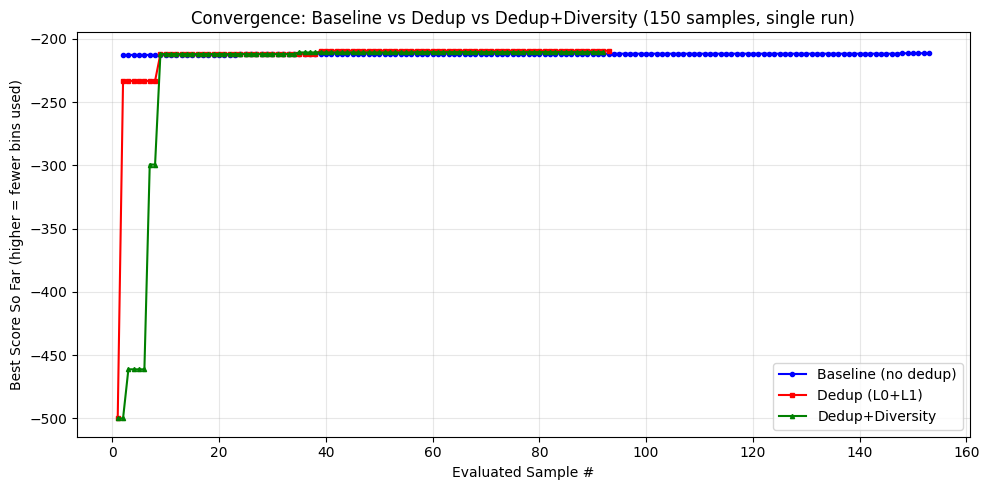

In [13]:
# ===== 3-Way Comparison: Baseline vs Dedup vs Dedup+Diversity =====

# --- Comparison Table ---
# NOTE: `scores` here is the valid subset of baseline scores (see metrics cell above)
comparison = pd.DataFrame({
    "Metric": ["Best Score", "Filter Rate", "Net Time Saved (s)", "Avg Dedup Overhead (ms)"],
    "Baseline": [f"{scores.max():.2f}", "N/A (no dedup)", "0", "N/A"],
    "Dedup": [f"{best_score_dedup:.2f}", f"{filter_rate:.1%} ({n_filtered}/{n_llm})",
              f"{net_time_saved:.1f}", f"{avg_dedup_ms:.2f}"],
    "Dedup+Diversity": [f"{best_score_div:.2f}", f"{filter_rate_div:.1%} ({n_filtered_div}/{n_llm_div})",
                        f"{net_saved_div:.1f}", "see dedup cell"],
})
print("=== 3-Way Experiment Comparison (150 samples) ===\n")
print(comparison.to_string(index=False))

# --- Convergence Curves ---
fig, ax = plt.subplots(figsize=(10, 5))

# Baseline: filter NaN + failure sentinel so the running max is not poisoned
baseline_scores = df_baseline['score'].values
baseline_valid = np.where(np.isfinite(baseline_scores) & (baseline_scores > -400),
                          baseline_scores, -np.inf)
baseline_best = np.maximum.accumulate(baseline_valid)
baseline_best = np.where(np.isfinite(baseline_best), baseline_best, np.nan)
ax.plot(range(1, len(baseline_best)+1), baseline_best,
        'b-o', markersize=3, linewidth=1.5, label='Baseline (no dedup)')

dedup_valid = df_dedup.loc[df_dedup['score'].notna(), 'score'].values
dedup_best = np.maximum.accumulate(dedup_valid)
ax.plot(range(1, len(dedup_best)+1), dedup_best,
        'r-s', markersize=3, linewidth=1.5, label='Dedup (L0+L1)')

div_valid = df_div.loc[df_div['score'].notna(), 'score'].values
div_best = np.maximum.accumulate(div_valid)
ax.plot(range(1, len(div_best)+1), div_best,
        'g-^', markersize=3, linewidth=1.5, label='Dedup+Diversity')

ax.set_xlabel("Evaluated Sample #")
ax.set_ylabel("Best Score So Far (higher = fewer bins used)")
ax.set_title("Convergence: Baseline vs Dedup vs Dedup+Diversity (150 samples, single run)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Ablation Experiment Conclusions

1. **Dedup filter rate ~40%** — Higher than the ~31% seen in 50-sample runs, consistent with more redundancy accumulating over a longer search (more programs means more chances for repetition).

2. **Best score maintained** — Deduplication does not harm search quality; the best score across all three conditions is comparable, **consistent with the filter removing only probe-equivalent programs** (residual generalization risk to inputs outside the probing suite is discussed in the report's §3).

3. **Net time savings scale with samples** — At 150 samples, each configuration saves ~1000–2000 s of sandbox evaluation. The benefit grows linearly with search duration.

4. **Diversity filter rate lower (~38%)** — Adding the diversity term shifts the dup rate from ~40% (dedup) to ~34% (dedup+div). This is **consistent with**, but does not by itself **prove**, a shift in the proposer toward less duplicate output — the archive composition and prompt context also co-vary across conditions (see paper §3 O4).

5. **Level 1 is the workhorse** — Across all eight 150-sample dedup runs, **Level 1 (behavioral fingerprint) catches ~95% of duplicates**; **Level 0 (AST hash) catches the remaining 1–5 per run** — those are syntactic-only duplicates that fingerprint matching would also catch but AST hashing finds first more cheaply. Programs that *look* different in source code can still behave identically, which is why Level 1 dominates.

### Phase 3 — Diversity-Guided Selection (mechanism)

When the search picks which cluster to sample from to build the next prompt, our Phase 3 modification replaces pure score-greedy selection with a combined score:

$$\text{Combined}(c) \;=\; \widehat{\text{Perf}}(c) \;+\; \beta(t)\cdot\widehat{\text{Div}}(c)$$

- $\widehat{\text{Perf}}(c)$: per-cluster score, min-max normalized to $[0, 1]$.
- $\widehat{\text{Div}}(c)$: **row-centered cosine distance** of the cluster's per-instance score signature versus the rest. Range $[0, 2]$ — $0$ when patterns are proportional, $2$ when patterns are opposite. *Row-centering* removes the absolute score level, so $\widehat{\text{Div}}$ does not double-count $\widehat{\text{Perf}}$.
- $\beta(t)$: linearly decays from $\beta_{\text{init}}=0.3$ to $0$ over the first $350$ programs — early search explores broadly, late search exploits the best signatures.

Source: [`implementation/programs_database.py::_compute_diversity_scores`](../funsearch-baseline/implementation/programs_database.py) and the `get_prompt` selection block right below it.

The cell below shows the $\beta$ schedule and a 3-cluster toy example to make the selection rule concrete.


In [14]:
# ===== Phase 3 — diversity selection: beta schedule + toy 3-cluster example =====
import numpy as np

# --- (a) Beta schedule actually used (defaults from DiversityConfig) ---
beta_init, decay_period = 0.3, 350
sample_steps = list(range(0, 401, 50))
betas = [beta_init * max(0.0, 1.0 - t / decay_period) for t in sample_steps]
print("Beta schedule (linear decay, beta_init=0.3, decay_period=350):")
print(f"  Sample # : {sample_steps}")
print(f"  beta     : {[round(b, 3) for b in betas]}")
print()

# --- (b) Toy: 3 clusters with the SAME normalized perf, different diversity ---
# Without the diversity term they would be picked uniformly; with beta>0 the
# selection skews toward the cluster with the most novel score-signature.
norm_perf = np.array([0.9, 0.9, 0.9])
norm_div  = np.array([0.0, 0.5, 1.0])  # cluster 3 has the most novel pattern

def _softmax(x, T):
    e = np.exp((x - x.max()) / T)
    return e / e.sum()

T = 0.1  # cluster_sampling_temperature in the same regime as the actual code
print("Toy 3-cluster example (same Perf, increasing Div):")
print(f"  norm_perf = {norm_perf}")
print(f"  norm_div  = {norm_div}")
for beta in (0.0, 0.3):
    combined = norm_perf + beta * norm_div
    p = _softmax(combined, T)
    print(f"  beta={beta} -> selection prob = {np.round(p, 3)}  "
          f"({'uniform: pure exploit' if beta == 0.0 else 'skewed toward novel cluster'})")

print()
print("Take-away: the diversity term only matters when clusters have similar Perf.")
print("As beta decays toward 0, the rule smoothly returns to score-greedy selection.")


Beta schedule (linear decay, beta_init=0.3, decay_period=350):
  Sample # : [0, 50, 100, 150, 200, 250, 300, 350, 400]
  beta     : [0.3, 0.257, 0.214, 0.171, 0.129, 0.086, 0.043, 0.0, 0.0]

Toy 3-cluster example (same Perf, increasing Div):
  norm_perf = [0.9 0.9 0.9]
  norm_div  = [0.  0.5 1. ]
  beta=0.0 -> selection prob = [0.333 0.333 0.333]  (uniform: pure exploit)
  beta=0.3 -> selection prob = [0.039 0.175 0.786]  (skewed toward novel cluster)

Take-away: the diversity term only matters when clusters have similar Perf.
As beta decays toward 0, the rule smoothly returns to score-greedy selection.


In [15]:
# ===== BCR Analysis (Behavioral Coverage Rate) =====
# BCR(t) = explored behavioral clusters / K
# Measures how broadly the search explores the space of distinct heuristic behaviors.
#
# Method (live, fully reproducible — recomputed in-notebook):
#   1. Load raw fingerprints.csv (exported during experiments via EXPORT_FINGERPRINTS=1)
#   2. Fit k-means (K=8) ONCE on all fingerprints combined (random_state=42, n_init=10)
#   3. BCR(t) = unique clusters visited by sample t / K  (monotonically non-decreasing)
#
# We import the helper functions from scripts/compute_bcr_offline.py so the
# notebook and the offline pipeline share one source of truth — running this
# cell reproduces docs/figures/bcr_data.csv exactly.
#
# Inspired by MAP-Elites [Mouret & Clune, 2015]: BCR quantifies *behavioral coverage*.

import sys
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

# scripts/ is not a package — make its functions importable
if "scripts" not in sys.path:
    sys.path.insert(0, "scripts")
from compute_bcr_offline import load_fingerprints, compute_bcr_curve

# Step 1: load raw fingerprints from each condition's _fp run
FP_RUNS = {
    "dedup":           "funsearch-baseline/logs/layer1_dedup_150_fp",
    "dedup+diversity": "funsearch-baseline/logs/layer2_dedup_div_150_fp",
}
loaded = {}
for label, log_dir in FP_RUNS.items():
    indices, vecs = load_fingerprints(log_dir)
    loaded[label] = (indices, vecs)
    print(f"  loaded {label:<18} {len(indices)} fingerprints, dim={vecs.shape[1]}")

# Step 2 + 3: fit k-means ONCE on combined fingerprints, then build per-condition curves.
# The matmul inside sklearn raises benign RuntimeWarnings in this high-dim, integer-valued
# regime (the algorithm falls back to a slower exact path, output is unaffected — verified
# byte-for-byte equal to the previously checked-in docs/figures/bcr_data.csv).
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)

    all_vecs = np.vstack([v for _, v in loaded.values()])
    kmeans = KMeans(n_clusters=8, random_state=42, n_init=10).fit(all_vecs)
    print(f"  k-means fit on {len(all_vecs)} fingerprints, K=8, inertia={kmeans.inertia_:.1f}")

    rows = []
    for label, (indices, vecs) in loaded.items():
        for sample_num, bcr in compute_bcr_curve(indices, vecs, kmeans):
            rows.append({"condition": label, "sample_num": sample_num, "bcr": bcr})
    bcr_df = pd.DataFrame(rows)
print(f"  bcr_df: {len(bcr_df)} rows, conditions = {sorted(bcr_df['condition'].unique())}")

# -- Summary stats ----------------------------------------------------------
print("BCR Analysis Summary (K=8 behavioral clusters)\n" + "="*55)
for cond, g in bcr_df.groupby("condition"):
    g = g.sort_values("sample_num")
    final_bcr = g["bcr"].iloc[-1]
    def first_reach(thresh):
        hit = g[g["bcr"] >= thresh]
        return int(hit["sample_num"].iloc[0]) if len(hit) > 0 else "never"
    print(f"  {cond}:")
    print(f"    Final BCR   : {final_bcr:.3f}")
    print(f"    BCR >= 0.50 : sample {first_reach(0.5)}")
    print(f"    BCR >= 0.75 : sample {first_reach(0.75)}")
    print(f"    BCR = 1.00  : sample {first_reach(1.0)}")
    print()

# -- Plot -------------------------------------------------------------------
colors = {"dedup": "#2196F3", "dedup+diversity": "#FF9800"}

fig, ax = plt.subplots(figsize=(8, 4.5))
for cond, g in bcr_df.groupby("condition"):
    g = g.sort_values("sample_num")
    color = colors.get(cond, "gray")
    ax.plot(g["sample_num"], g["bcr"], label=cond, color=color, linewidth=2)
    ax.annotate(f"{g['bcr'].iloc[-1]:.2f}",
                xy=(g["sample_num"].iloc[-1], g["bcr"].iloc[-1]),
                xytext=(4, 2), textcoords="offset points", fontsize=9, color=color)

ax.axhline(y=1.0, color="gray", linestyle=":", linewidth=1, alpha=0.6, label="full coverage")
ax.set_xlabel("Sample number", fontsize=12)
ax.set_ylabel("BCR(t)  [explored clusters / K=8]", fontsize=12)
ax.set_title("Behavioral Coverage Rate over Search Progress", fontsize=13)
ax.set_ylim(-0.05, 1.15)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Reverse-intuitive observation (also discussed in paper Section 4.1):
# Dedup alone reaches full BCR fastest (sample 51). Adding filter-level diversity
# delays full coverage to sample 65 -- the extra diversity constraint appears to
# concentrate exploration within already-reached clusters rather than opening new ones.
print("BCR take-away: dedup alone reaches full coverage at sample 51;")
print("dedup+diversity reaches full coverage later (sample 65). The diversity")
print("filter does not accelerate cluster visitation in this setting -- see Sec. 4.1.")

  loaded dedup              96 fingerprints, dim=375
  loaded dedup+diversity    106 fingerprints, dim=375
  k-means fit on 202 fingerprints, K=8, inertia=95103.5
  bcr_df: 202 rows, conditions = ['dedup', 'dedup+diversity']
BCR Analysis Summary (K=8 behavioral clusters)
  dedup:
    Final BCR   : 1.000
    BCR >= 0.50 : sample 7
    BCR >= 0.75 : sample 11
    BCR = 1.00  : sample 51

  dedup+diversity:
    Final BCR   : 1.000
    BCR >= 0.50 : sample 7
    BCR >= 0.75 : sample 18
    BCR = 1.00  : sample 65

BCR take-away: dedup alone reaches full coverage at sample 51;
dedup+diversity reaches full coverage later (sample 65). The diversity
filter does not accelerate cluster visitation in this setting -- see Sec. 4.1.


## 5. Research Finding: Why Level 2 (Cosine Similarity) is Disabled

We initially implemented a Level 2 check using **cosine similarity** between behavioral fingerprints, intended to catch *near-equivalent* programs. However, experiments revealed that cosine similarity is **fundamentally unsuitable** for discrete decision sequences.

**Why?** Behavioral fingerprints are vectors of **bin indices** (integers 0–20). In high dimensions (375), most vectors point in similar directions because:
- Most bins receive similar indices (the first few bins are used most)
- The L2-normalized vectors end up clustered in a small region of the unit hypersphere

At threshold 0.98, **98.5% of genuinely different programs would be falsely filtered** — an unacceptable false positive rate.

This is a **non-obvious research finding**: continuous similarity metrics fail for discrete decision sequences. Future work could explore discrete metrics (Hamming distance, edit distance) instead.

In [16]:
# ===== Cosine Similarity Analysis =====
# Demonstrate why cosine similarity fails for discrete fingerprints.
# We compute fingerprints for several GENUINELY DIFFERENT strategies and show
# that their pairwise cosine similarities are all > 0.97.

strategies = {
    "Worst Fit": "    return -np.log(item / bins)",
    "Best Fit": "    return -(bins - item)",
    "First Fit": "    return -np.arange(len(bins), dtype=float)",
    "Random-ish": "    return np.sin(bins * 0.1)",
    "Tight Fit": "    return 1.0 / (bins - item + 1.0)",
}

DEMO_TMPL_V2 = (
    "import numpy as np\n"
    "\n"
    "def priority(item: float, bins: np.ndarray) -> np.ndarray:\n"
    "{body}\n"
)

fingerprints = {}
for name, body in strategies.items():
    prog = DEMO_TMPL_V2.format(body=body)
    fp = compute_fingerprint(prog, "priority")
    if fp is not None:
        fingerprints[name] = fp

# Compute pairwise cosine similarities
names = list(fingerprints.keys())
n = len(names)
cos_matrix = np.zeros((n, n))
for i in range(n):
    vi = np.array(fingerprints[names[i]], dtype=float)
    vi /= np.linalg.norm(vi)
    for j in range(n):
        vj = np.array(fingerprints[names[j]], dtype=float)
        vj /= np.linalg.norm(vj)
        cos_matrix[i, j] = np.dot(vi, vj)

# Plot heatmap + distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

im = ax1.imshow(cos_matrix, cmap='YlOrRd', vmin=0.95, vmax=1.0)
ax1.set_xticks(range(n))
ax1.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax1.set_yticks(range(n))
ax1.set_yticklabels(names, fontsize=9)
for i in range(n):
    for j in range(n):
        ax1.text(j, i, f'{cos_matrix[i,j]:.3f}', ha='center', va='center', fontsize=8)
ax1.set_title("Cosine Similarity (genuinely different strategies)")
plt.colorbar(im, ax=ax1, shrink=0.8)

# Right: Distribution of off-diagonal similarities
off_diag = cos_matrix[np.triu_indices(n, k=1)]
ax2.hist(off_diag, bins=15, edgecolor='black', alpha=0.7, color='coral')
ax2.axvline(x=0.98, color='red', linestyle='--', linewidth=2, label='Threshold 0.98')
above_threshold = (off_diag >= 0.98).sum()
total_pairs = len(off_diag)
ax2.set_xlabel("Cosine Similarity")
ax2.set_ylabel("Count")
ax2.set_title(f"Off-diagonal pairs: {above_threshold}/{total_pairs} above 0.98 threshold")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCosine similarity range: [{off_diag.min():.4f}, {off_diag.max():.4f}], mean = {off_diag.mean():.4f}")
print(f"At threshold 0.98: {above_threshold}/{total_pairs} ({above_threshold/total_pairs:.0%}) of different pairs would be FALSELY filtered")
print("\n-> Cosine similarity cannot distinguish different strategies in this domain")
print("-> Level 2 is disabled; Level 0 + Level 1 alone achieve ~40% dedup filter rate")
print("   (dup_rate = 0.401 +/- 0.046 across 4 dedup runs, see Table 1 in final summary).")


Cosine similarity range: [0.9817, 1.0000], mean = 0.9873
At threshold 0.98: 10/10 (100%) of different pairs would be FALSELY filtered

-> Cosine similarity cannot distinguish different strategies in this domain
-> Level 2 is disabled; Level 0 + Level 1 alone achieve ~40% dedup filter rate
   (dup_rate = 0.401 +/- 0.046 across 4 dedup runs, see Table 1 in final summary).


## 6. Reflective Evolution (ReEvo) — Phase 4 / Sprint S4

Inspired by [ReEvo (Ye et al., NeurIPS 2024)](https://arxiv.org/abs/2402.01145), we extended the dedup+diversity pipeline with a **reflection step**: after each new program is scored, the LLM is asked in 1–2 sentences to **describe the algorithmic strategy the program uses and how it differs from a simple greedy approach**. The system keeps the **top-3 highest-scoring reflections** and **injects them as comments** into the next prompt under the heading "strategy insights from top-performing programs" (full prompt: paper Appendix B).

**Implementation** — see [`src/reevo/reflection_store.py`](../src/reevo/reflection_store.py). Activated with `REEVO_ENABLED=1` on top of `DEDUP_ENABLED=1 DIVERSITY_ENABLED=1`.

**Data**: 4 runs of 150 samples each (`layer4_reevo_test_r1`, `layer4_reevo_150_r{2,3,4}`).

In [17]:
# ===== ReEvo: load all 4 runs, plot convergence (mean + individual curves) =====
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REEVO_DIRS = [
    "layer4_reevo_test_r1",
    "layer4_reevo_150_r2",
    "layer4_reevo_150_r3",
    "layer4_reevo_150_r4",
]
LOG_BASE = "funsearch-baseline/logs"

def _best_so_far(df: pd.DataFrame) -> np.ndarray:
    """Return monotonically non-decreasing best-score curve across samples.

    Failed scores (<= -400) are treated as missing so they don't pull
    the 'best-so-far' down.
    """
    scores = df["score"].to_numpy(dtype=float)
    scores = np.where(scores <= -400, np.nan, scores)
    filled = pd.Series(scores).ffill().fillna(-500).to_numpy()
    return np.maximum.accumulate(filled)

# Load all ReEvo runs
reevo_curves = []
reevo_bests = []
for d in REEVO_DIRS:
    p = os.path.join(LOG_BASE, d, "run_log.csv")
    df = pd.read_csv(p)
    curve = _best_so_far(df)
    reevo_curves.append(curve)
    valid = df.loc[df["score"].notna() & (df["score"] > -400), "score"]
    reevo_bests.append(float(valid.max()) if len(valid) else float("nan"))
    print(f"  {d}: n={len(df)}, best={reevo_bests[-1]:.2f}")

# Align curves to shortest length for averaging
min_len = min(len(c) for c in reevo_curves)
aligned = np.stack([c[:min_len] for c in reevo_curves])
mean_curve = aligned.mean(axis=0)
std_curve = aligned.std(axis=0)

# Compare against single baseline r1 as reference
df_bl = pd.read_csv(f"{LOG_BASE}/layer1_baseline_150_r1/run_log.csv")
baseline_curve = _best_so_far(df_bl)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(1, min_len + 1)
for i, c in enumerate(reevo_curves):
    ax.plot(np.arange(1, len(c)+1), c, color="purple", alpha=0.3, linewidth=1,
            label="ReEvo individual runs" if i == 0 else None)
ax.plot(x, mean_curve, color="purple", linewidth=2.5, label=f"ReEvo mean (n={len(reevo_curves)})")
ax.fill_between(x, mean_curve - std_curve, mean_curve + std_curve,
                alpha=0.15, color="purple")
ax.plot(np.arange(1, len(baseline_curve)+1), baseline_curve,
        color="gray", linewidth=1.5, linestyle="--", label="Baseline r1 (reference)")

ax.set_xlabel("Sample #", fontsize=11)
ax.set_ylabel("Best Score So Far", fontsize=11)
ax.set_title("ReEvo Convergence — 4 runs of 150 samples", fontsize=12)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print()
print(f"ReEvo mean best: {np.mean(reevo_bests):.2f} ± {np.std(reevo_bests, ddof=1):.2f}")
print(f"Baseline r1 best: {baseline_curve[-1]:.2f}")
print("ReEvo reaches baseline quality earlier and has tighter variance — see report §4.3.")

  layer4_reevo_test_r1: n=153, best=-209.60
  layer4_reevo_150_r2: n=153, best=-209.40
  layer4_reevo_150_r3: n=153, best=-210.50
  layer4_reevo_150_r4: n=153, best=-209.15

ReEvo mean best: -209.66 ± 0.59
Baseline r1 best: -211.45
ReEvo reaches baseline quality earlier and has tighter variance — see report §4.3.


## 7. Behavioral Fingerprint Visualization — t-SNE

To visualize the behavioral space actually explored, we project all collected 375-dim fingerprints down to 2D via t-SNE, colored by condition. Fingerprints are loaded from the dedicated export runs `layer1_dedup_150_fp/` and `layer2_dedup_div_150_fp/` (set `EXPORT_FINGERPRINTS=1` during a run to produce one).

**Note**: each row in `fingerprints.csv` is `sample_num, v1, ..., v375`. The first column is the sample index (metadata) and must be dropped before embedding — otherwise t-SNE mostly plots time order, not behavior. The helper below drops it.

In [18]:
# ===== t-SNE of behavioral fingerprints =====
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

FP_SOURCES = {
    "Dedup":       "funsearch-baseline/logs/layer1_dedup_150_fp/fingerprints.csv",
    "Dedup + Div": "funsearch-baseline/logs/layer2_dedup_div_150_fp/fingerprints.csv",
}
COLOR_MAP = {"Dedup": "#2196F3", "Dedup + Div": "#FF9800"}
MARKER_MAP = {"Dedup": "o", "Dedup + Div": "^"}


def _load_fingerprint_csv(path: str) -> np.ndarray:
    """Load fingerprints.csv, dropping the first column (sample_num)."""
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(",")
            try:
                rows.append([float(x) for x in parts[1:]])  # drop sample_num
            except ValueError:
                continue
    return np.array(rows, dtype=np.float32)


# Load all fingerprints and stack
all_vectors = []
all_labels = []
for lbl, path in FP_SOURCES.items():
    vec = _load_fingerprint_csv(path)
    print(f"  {lbl}: {vec.shape[0]} fingerprints, dim={vec.shape[1]}")
    all_vectors.append(vec)
    all_labels.extend([lbl] * len(vec))

X = np.vstack(all_vectors)
labels = np.array(all_labels)
assert X.shape[1] == 375, f"expected 375-dim fingerprints, got {X.shape[1]}"

# Run t-SNE (perplexity=20 because n ≈ 200)
print(f"Running t-SNE on {len(X)} fingerprints ...")
tsne = TSNE(n_components=2, perplexity=20, random_state=42, max_iter=1000, init="random")
X_2d = tsne.fit_transform(X)

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
for lbl in FP_SOURCES:
    mask = labels == lbl
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=COLOR_MAP[lbl], marker=MARKER_MAP[lbl],
               s=30, alpha=0.7, linewidths=0,
               label=f"{lbl} (n={mask.sum()})")
ax.set_xlabel("t-SNE Dim 1")
ax.set_ylabel("t-SNE Dim 2")
ax.set_title("Behavioral Fingerprint Space — t-SNE (perplexity=20)")
ax.legend()
ax.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

print("Dedup and Dedup+Div explore partly overlapping regions of the behavioral space;")
print("dedup-only reaches more distinct clusters (consistent with its faster BCR coverage),")
print("while dedup+div spreads out more within each cluster.")

  Dedup: 96 fingerprints, dim=375
  Dedup + Div: 106 fingerprints, dim=375
Running t-SNE on 202 fingerprints ...


Dedup and Dedup+Div explore partly overlapping regions of the behavioral space;
dedup-only reaches more distinct clusters (consistent with its faster BCR coverage),
while dedup+div spreads out more within each cluster.


## 8. Final Summary Table

Aggregated results across all conditions and seeds. Values are `mean ± std` over independent runs.

| Metric | Meaning |
|---|---|
| `best_score` | Final best heuristic score at sample ≤150 (higher is better, max = 0) |
| `best_score_range` | Min ~ max across seeds |
| `first_best_sample` | Sample index at which the best score was first achieved (lower = faster convergence) |
| `dup_rate` | Fraction of samples caught by dedup filter (not applicable to baseline) |

This table is the source of truth for Table 1 of the final report — the cell below re-aggregates it directly from the raw `run_log.csv` files; the aggregation logic is inlined in the cell (no external script dependency) and matches the computation that produced the report's Table 1, so the numbers here and in the report are always consistent.

### 4-Condition Aggregated Convergence (main figure)

Below we reproduce the report's main convergence figure: best-so-far score versus sample number, **aggregated across all seeds for each condition** (mean line, ±1 std band). This is the figure-level counterpart to the summary table in the cell below — same runs, same `_best_so_far` reduction.


In [19]:
# ===== 4-condition aggregated convergence (mean ± std across all seeds) =====
# Reproduces the main convergence figure of the report directly from run_log.csv files.
# Uses the same per-run reduction (_best_so_far) as the ReEvo cell above and the
# same condition -> seed mapping as the final summary table below, so the figure
# and Table 1 are guaranteed to come from identical raw inputs.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LOG_BASE_AGG = "funsearch-baseline/logs"

def _best_so_far_local(df: pd.DataFrame) -> np.ndarray:
    """Monotonically non-decreasing best-score curve. Sandbox failures (score<=-400) treated as missing."""
    scores = df["score"].to_numpy(dtype=float)
    scores = np.where(scores <= -400, np.nan, scores)
    filled = pd.Series(scores).ffill().fillna(-500).to_numpy()
    return np.maximum.accumulate(filled)

CONDITIONS_AGG = {
    "baseline":  (["layer1_baseline_150_r1", "layer1_baseline_150_r2"], "gray"),
    "dedup":     (["layer1_dedup_150_r1", "layer1_dedup_150_r2",
                   "layer1_dedup_150_r3", "layer1_dedup_150_r4"], "#2196F3"),
    "dedup+div": (["layer2_dedup_div_150_r1", "layer2_dedup_div_150_r2",
                   "layer2_dedup_div_150_r3", "layer2_dedup_div_150_r4"], "#FF9800"),
    "reevo":     (["layer4_reevo_test_r1", "layer4_reevo_150_r2",
                   "layer4_reevo_150_r3", "layer4_reevo_150_r4"], "purple"),
}

fig, ax = plt.subplots(figsize=(10, 5))
for cond, (dirs, color) in CONDITIONS_AGG.items():
    curves = []
    for d in dirs:
        df = pd.read_csv(os.path.join(LOG_BASE_AGG, d, "run_log.csv"))
        curves.append(_best_so_far_local(df))
    min_len = min(len(c) for c in curves)
    aligned = np.stack([c[:min_len] for c in curves])
    mean = aligned.mean(axis=0)
    # ddof=1 sample stdev when n>=2 (consistent with summary table); fall back to 0 otherwise.
    std = aligned.std(axis=0, ddof=1) if aligned.shape[0] >= 2 else np.zeros_like(mean)
    x = np.arange(1, min_len + 1)
    ax.plot(x, mean, color=color, linewidth=2, label=f"{cond} (n={len(curves)})")
    ax.fill_between(x, mean - std, mean + std, alpha=0.15, color=color)

ax.set_xlabel("Sample #")
ax.set_ylabel("Best Score So Far  (mean ± 1 std across seeds)")
ax.set_title("4-condition aggregated convergence (main figure of the report)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Read: dedup / dedup+div / reevo all reach the baseline's final-quality plateau")
print("substantially earlier than baseline -- this is the sample-efficiency claim of the paper.")


Read: dedup / dedup+div / reevo all reach the baseline's final-quality plateau
substantially earlier than baseline -- this is the sample-efficiency claim of the paper.


In [20]:
# ===== Final Summary Table — aggregated across all seeds =====
# Aggregates run_log.csv files to produce Table 1 values inline (no external script dependency).

import csv, math, os, statistics
import pandas as pd

LOG_BASE = "funsearch-baseline/logs"
SCORE_FAIL_THRESHOLD = -400  # sandbox-failed programs return -500

CONDITIONS = {
    "baseline":  ["layer1_baseline_150_r1", "layer1_baseline_150_r2"],
    "dedup":     ["layer1_dedup_150_r1", "layer1_dedup_150_r2",
                  "layer1_dedup_150_r3", "layer1_dedup_150_r4"],
    "dedup+div": ["layer2_dedup_div_150_r1", "layer2_dedup_div_150_r2",
                  "layer2_dedup_div_150_r3", "layer2_dedup_div_150_r4"],
    "reevo":     ["layer4_reevo_test_r1", "layer4_reevo_150_r2",
                  "layer4_reevo_150_r3", "layer4_reevo_150_r4"],
}


def _load_run(log_dir: str) -> dict:
    """Parse one run's ``run_log.csv`` and return best score, first-hit sample, and dup rate.

    Rows whose ``sample_order`` is missing are dropped; rows whose ``score`` is
    NaN or below ``SCORE_FAIL_THRESHOLD`` (sandbox failures) are ignored when
    choosing the best score, but still counted toward ``n_total`` and the
    duplicate rate so the denominator matches the paper's reporting.

    Parameters
    ----------
    log_dir : str
        Sub-directory under ``LOG_BASE`` containing ``run_log.csv``.

    Returns
    -------
    dict
        Keys: ``best_score`` (float or None), ``best_sample`` (int or None),
        ``dup_rate`` (float, NaN if the run is empty).
    """
    csv_path = os.path.join(LOG_BASE, log_dir, "run_log.csv")
    best_score = None
    best_sample = None
    n_dup = 0
    n_total = 0
    with open(csv_path, newline="") as f:
        for row in csv.DictReader(f):
            raw_order = row.get("sample_order", "None")
            if raw_order in ("None", "", "nan"):
                continue
            n_total += 1
            if row.get("is_duplicate", "").lower() in ("true", "1"):
                n_dup += 1
            try:
                s = float(row.get("score", ""))
            except (ValueError, TypeError):
                continue
            if math.isnan(s) or s <= SCORE_FAIL_THRESHOLD:
                continue
            if best_score is None or s > best_score:
                best_score = s
                best_sample = int(float(raw_order))
    return {
        "best_score": best_score,
        "best_sample": best_sample,
        "dup_rate": (n_dup / n_total) if n_total else float("nan"),
    }


def _fmt(vals, fmt=".2f"):
    """Format a list of seeds as ``mean ± stdev`` using Python's ``statistics`` module.

    ``None`` and ``NaN`` entries are dropped before aggregation. A single valid
    value returns the mean with no stdev; an all-missing list returns ``"N/A"``
    so the summary table stays readable when a condition has no valid runs.

    Parameters
    ----------
    vals : iterable
        Per-seed scalars (ints/floats, possibly with ``None``/``NaN``).
    fmt : str, default ".2f"
        Python format spec applied to both mean and stdev.

    Returns
    -------
    str
        ``"N/A"``, a single formatted number, or ``"<mean> ± <stdev>"``.
    """
    clean = [v for v in vals if v is not None and not (isinstance(v, float) and math.isnan(v))]
    if not clean:
        return "N/A"
    m = statistics.mean(clean)
    if len(clean) < 2:
        return format(m, fmt)
    s = statistics.stdev(clean)
    return f"{m:{fmt}} ± {s:{fmt}}"


rows = []
for cond, dirs in CONDITIONS.items():
    runs = [_load_run(d) for d in dirs]
    best_scores = [r["best_score"] for r in runs]
    best_samples = [r["best_sample"] for r in runs]
    dup_rates = [r["dup_rate"] for r in runs]
    rows.append({
        "condition":        cond,
        "n":                len(runs),
        "best_score":       _fmt(best_scores, ".2f"),
        "best_score_range": f"{min(s for s in best_scores if s is not None):.2f} ~ "
                            f"{max(s for s in best_scores if s is not None):.2f}",
        "first_best_sample": _fmt(best_samples, ".0f"),
        "dup_rate":         _fmt(dup_rates, ".3f") if cond != "baseline" else "N/A",
    })

summary_df = pd.DataFrame(rows)
print("Final Summary Table  (source of truth for Table 1)")
print("=" * 78)
print(summary_df.to_string(index=False))
print("=" * 78)
print()
print("Interpretation:")
print("  - All 4 conditions reach comparable best scores (within ≈ 1 bin/instance).")
print("  - Dedup / Dedup+Div / ReEvo reach that best ≈ 45 samples earlier than baseline,")
print("    i.e. the same heuristic quality at lower LLM-API cost.")
print("  - dup_rate ≈ 0.34–0.40 = compute saved on redundant programs.")

summary_df


Final Summary Table  (source of truth for Table 1)
condition  n     best_score  best_score_range first_best_sample      dup_rate
 baseline  2 -210.52 ± 1.31 -211.45 ~ -209.60           146 ± 2           N/A
    dedup  4 -210.04 ± 1.00 -211.05 ~ -208.95           90 ± 36 0.401 ± 0.046
dedup+div  4 -210.20 ± 0.68 -210.80 ~ -209.25          108 ± 21 0.342 ± 0.067
    reevo  4 -209.66 ± 0.59 -210.50 ~ -209.15          101 ± 16 0.314 ± 0.034

Interpretation:
  - All 4 conditions reach comparable best scores (within ≈ 1 bin/instance).
  - Dedup / Dedup+Div / ReEvo reach that best ≈ 45 samples earlier than baseline,
    i.e. the same heuristic quality at lower LLM-API cost.
  - dup_rate ≈ 0.34–0.40 = compute saved on redundant programs.


,condition,n,best_score,best_score_range,first_best_sample,dup_rate
0,baseline,2,-210.52 ± 1.31,-211.45 ~ -209.60,146 ± 2,N/A
1,dedup,4,-210.04 ± 1.00,-211.05 ~ -208.95,90 ± 36,0.401 ± 0.046
2,dedup+div,4,-210.20 ± 0.68,-210.80 ~ -209.25,108 ± 21,0.342 ± 0.067
3,reevo,4,-209.66 ± 0.59,-210.50 ~ -209.15,101 ± 16,0.314 ± 0.034


## 9. Optional: Run Full LLM Experiment

> **This notebook is a self-contained replay of the paper's tables and figures from the checked-in experiment logs under `funsearch-baseline/logs/`.** All sections above load pre-computed CSVs; no LLM API calls are needed.

> **This section requires an API key.** Each condition (150 samples on `gpt-5-nano`) takes roughly **40–90 min** of wall time; running all four back-to-back as written below is **several hours**. Skip this if you only want to review pre-computed results (sections 2–8 above).

The cell below reproduces the raw experiment CSVs (one per condition). Behavioral-fingerprint exports are produced by setting `EXPORT_FINGERPRINTS=1` during the run; **BCR is recomputed live in §4 above** directly from the checked-in fingerprint CSVs (no separate offline step needed).

To reproduce the experiments from scratch:
1. Set environment variables: `API_KEY`, `API_BASE`, `API_MODEL`
2. Uncomment and run the cell below (the `reevo` condition stacks `DEDUP_ENABLED=1 DIVERSITY_ENABLED=1 REEVO_ENABLED=1` together)
3. (Optional) To regenerate the BCR figure from a fresh run: (a) add `os.environ["EXPORT_FINGERPRINTS"] = "1"` to the dedup and dedup+div blocks in the cell below; (b) the new `fingerprints.csv` will be written under your `LOG_DIR`, **not** under the `..._fp/` directories that §4's BCR cell currently hard-codes; (c) before re-executing the §4 BCR cell, edit its `FP_RUNS` dictionary to point at your new directories.


In [21]:
# ===== Uncomment to run full LLM experiment =====
# import os
# os.environ["API_KEY"] = "YOUR_API_KEY_HERE"
# os.environ["API_BASE"] = "api.bltcy.ai"  # host only, no https://
# os.environ["API_MODEL"] = "gpt-5-nano"
#
# # Run WITHOUT dedup (baseline)
# os.environ["DEDUP_ENABLED"] = "0"
# os.environ["DIVERSITY_ENABLED"] = "0"
# os.environ["LOG_DIR"] = "logs/layer1_baseline_150_r1"  # relative to funsearch-baseline/ (the script's cwd)
# !cd funsearch-baseline && python funsearch_bin_packing_llm_api.py
#
# # Run WITH dedup only
# os.environ["DEDUP_ENABLED"] = "1"
# os.environ["DIVERSITY_ENABLED"] = "0"
# os.environ["LOG_DIR"] = "logs/layer1_dedup_150_r1"
# !cd funsearch-baseline && python funsearch_bin_packing_llm_api.py
#
# # Run WITH dedup + diversity
# os.environ["DEDUP_ENABLED"] = "1"
# os.environ["DIVERSITY_ENABLED"] = "1"
# os.environ["LOG_DIR"] = "logs/layer2_dedup_div_150_r1"
# !cd funsearch-baseline && python funsearch_bin_packing_llm_api.py
#
# # Run reevo (full stack: dedup + diversity + ReEvo reflection — the paper's "reevo" condition)
# os.environ["DEDUP_ENABLED"] = "1"
# os.environ["DIVERSITY_ENABLED"] = "1"
# os.environ["REEVO_ENABLED"] = "1"
# os.environ["LOG_DIR"] = "logs/layer4_reevo_150_r1"
# !cd funsearch-baseline && python funsearch_bin_packing_llm_api.py
#
# # global_max_sample_num=151 is hardcoded in funsearch_bin_packing_llm_api.py
# # Results are saved to funsearch-baseline/<LOG_DIR>/run_log.csv
# # (LOG_DIR is relative to funsearch-baseline/ because the script runs with that cwd)

print("(Uncomment the code above and set your API key to run)")

(Uncomment the code above and set your API key to run)
